# EduLens: AI-Powered Inclusive Education Assistant

**Gemma 4 Good Hackathon - Education & Digital Equity Track**

EduLens uses Gemma 4 multimodal understanding + native function calling to create an inclusive education assistant.

**Key Features:** Multimodal input | Function calling tools | 140+ languages | Edge-deployable (3.2GB)

## 1. Setup

In [1]:
import subprocess, sys

# Install PyTorch 2.5.1 compatible with P100 (sm_60) GPU
subprocess.run(
    'pip install torch==2.5.1+cu121 torchvision==0.20.1+cu121 '
    '--index-url https://download.pytorch.org/whl/cu121 -q --force-reinstall --no-deps',
    shell=True, check=True
)
# Install transformers, Gradio, and other dependencies
subprocess.run('pip install -U transformers accelerate Pillow gradio -q', shell=True, check=True)
print('Setup complete! (PyTorch + Transformers + Gradio)')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 117.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.8/36.8 MB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 44.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.5.1+cu121 which is incompatible.


Setup complete! (PyTorch + Transformers + Gradio)


## 2. Run Inference

We run model inference in a subprocess to use the freshly installed PyTorch.

In [2]:
import base64, os

encoded_script = '...'

script = base64.b64decode(encoded_script).decode()
with open('/kaggle/working/run_inference.py', 'w') as f:
    f.write(script)
print(f'Inference script written ({len(script)} bytes)')

Inference script written (20445 bytes)


In [3]:
import subprocess, sys

result = subprocess.run(
    [sys.executable, '/kaggle/working/run_inference.py'],
    capture_output=True, text=True, timeout=3600
)

print(result.stdout)
if result.returncode != 0:
    print('\n=== ERRORS ===')
    print(result.stderr[-2000:])

PyTorch: 2.5.1+cu121, CUDA: True
GPU: Tesla P100-PCIE-16GB
Loading google/gemma-4-e2b-it...
Model loaded!
Demo images created.

DEMO 1: Math Problem Solving (Multimodal + Image)
Hello! I'm EduLens, and I'd be happy to help you with your math problem. Dealing with quadratic equations can seem tricky at first, but if we take it step-by-step, you'll see it's totally manageable! Don't worry; we'll get through this together. 😊

Here is the analysis, explanation, practice questions, and encouragement you asked for!

***

### 1. Content Analysis

Based on the image you shared, here is what I found:

*   **Subject:** Mathematics
*   **Topic:** Quadratic Equations (Solving using the Quadratic Formula)
*   **Difficulty:** High School
*   **Key Concepts:**
    *   Quadratic Equation ($ax^2 + bx + c = 0$)
    *   The Quadratic Formula: $x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$
    *   Identifying the coefficients ($a$, $b$, and $c$) in an equation.
    *   Substitution and simplification.

### 2. S

## 3. Display Results

**math.png:**

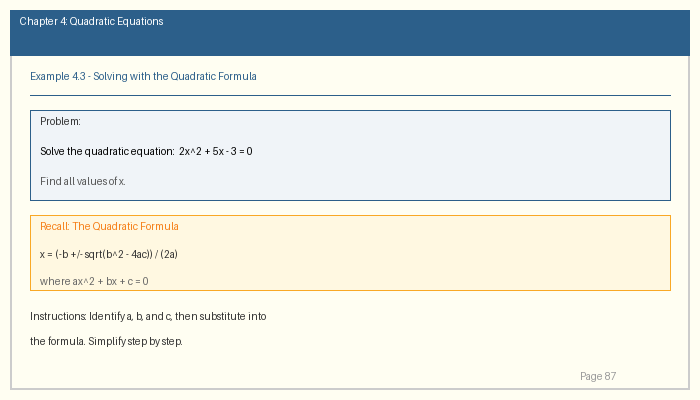

**science.png:**

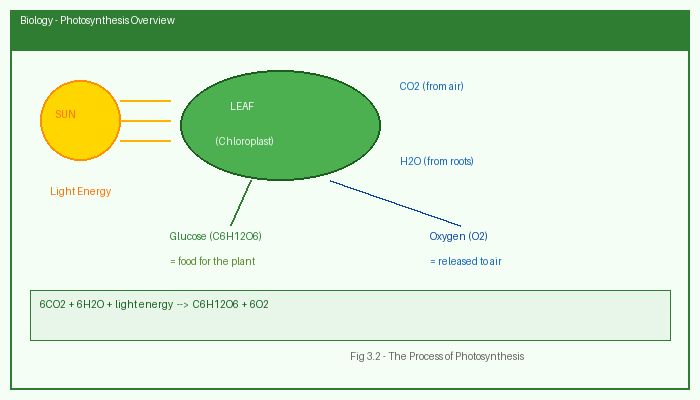

---
### demo1_math

Hello! I'm EduLens, and I'd be happy to help you with your math problem. Dealing with quadratic equations can seem tricky at first, but if we take it step-by-step, you'll see it's totally manageable! Don't worry; we'll get through this together. 😊

Here is the analysis, explanation, practice questions, and encouragement you asked for!

***

### 1. Content Analysis

Based on the image you shared, here is what I found:

*   **Subject:** Mathematics
*   **Topic:** Quadratic Equations (Solving using the Quadratic Formula)
*   **Difficulty:** High School
*   **Key Concepts:**
    *   Quadratic Equation ($ax^2 + bx + c = 0$)
    *   The Quadratic Formula: $x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$
    *   Identifying the coefficients ($a$, $b$, and $c$) in an equation.
    *   Substitution and simplification.

### 2. Step-by-Step Explanation

Your problem is to **Solve the quadratic equation: $2x^2 + 5x - 3 = 0$**. We will use the **Quadratic Formula**, which is given as: $$x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$$

Here is how we apply it step-by-step:

**Step 1: Identify $a$, $b$, and $c$.**
First, compare your equation ($2x^2 + 5x - 3 = 0$) to the standard form ($ax^2 + bx + c = 0$).
*   $a$ is the number in front of $x^2$: $\mathbf{a = 2}$
*   $b$ is the number in front of $x$: $\mathbf{b = 5}$
*   $c$ is the constant number at the end: $\mathbf{c = -3}$ (Don't forget the negative sign!)

**Step 2: Substitute these values into the Quadratic Formula.**
Now, plug $a=2$, $b=5$, and $c=-3$ into the formula:
$$x = \frac{-(5) \pm \sqrt{(5)^2 - 4(2)(-3)}}{2(2)}$$

**Step 3: Simplify inside the square root (the discriminant).**
Calculate the part under the square root first:
*   $(5)^2 = 25$
*   $-4(2)(-3) = (-8)(-3) = +24$
*   So, the expression under the root is: $25 + 24 = 49$

The formula now looks like this:
$$x = \frac{-5 \pm \sqrt{49}}{4}$$

**Step 4: Calculate the square root.**
Find the square root of 49:
*   $\sqrt{49} = 7$

The formula becomes:
$$x = \frac{-5 \pm 7}{4}$$

**Step 5: Find the two separate solutions for $x$.**
Because of the "$\pm$" (plus or minus), we have two possible answers: one using addition and one using subtraction.

*   **Solution 1 (using +):**
    $$x_1 = \frac{-5 + 7}{4} = \frac{2}{4} = \frac{1}{2}$$

*   **Solution 2 (using -):**
    $$x_2 = \frac{-5 - 7}{4} = \frac{-12}{4} = -3$$

**Answer:** The two values of $x$ that solve the equation $2x^2 + 5x - 3 = 0$ are $\mathbf{x = \frac{1}{2}}$ and $\mathbf{x = -3}$.

See? You did great! By following those steps—identify, substitute, simplify the root, and split the answer—you successfully solved the equation. Keep practicing this process, and you'll master quadratics in no time! 🎉

### 3. Practice Questions

To make sure you feel confident, here are a few practice problems for you. Try solving these on your own first!

1.  Solve for $x$: $x^2 + 5x + 6 = 0$
2.  Solve for $x$: $x^2 - 4x + 3 = 0$
3.  Solve for $x$: $3x^2 - 5x + 2 = 0$

Let me know when you have your answers

---
### demo2_chinese

你好！我是 EduLens，很高兴能帮助你学习生物知识。不用担心，我会用你容易理解的中文来一步一步地解释这张图，让你对光合作用（Photosynthesis）有一个清晰的认识！💪

---

### 🌟 **第一步：内容分析 (Content Analysis)**

*   **学科 (Subject):** 科学 (Science)
*   **主题 (Topic):** 光合作用 (Photosynthesis) 的概述 (Overview)
*   **难度 (Difficulty):** 初中级 (Middle School)
*   **关键概念 (Key Concepts):** 太阳能 (Light Energy)、叶绿体 (Chloroplast)、二氧化碳 ($\text{CO}_2$)、水 ($\text{H}_2\text{O}$)、葡萄糖 (Glucose)，以及光合作用的化学方程式。

---

### 📝 **第二步：详细解释 (Step-by-Step Explanation)**

这张图片展示了植物如何利用阳光将二氧化碳和水转化为食物（葡萄糖）的过程，这就是**光合作用**。你可以把它想象成植物自己的“小厨房”！

下面我们来一步一步解读图中的元素和过程：

1.  **能量来源 (The Energy Source): ☀️ 太阳能 (Light Energy)**
    *   这是整个过程的**驱动力**，就像我们做任何事情都需要电一样，植物需要太阳的光能来启动这个过程。

2.  **参与者 (The Ingredients/Reactants): 🌱 叶子与原料**
    *   **叶子 (LEAF)：** 这是进行光合作用的主要场所。在叶子的细胞里有一个非常重要的结构叫做**叶绿体 (Chloroplast)**。叶绿体里面含有绿色物质——叶绿素，它负责捕捉太阳光。
    *   **$\text{CO}_2$ (from air) - 二氧化碳 (来自空气):** 植物从空气中吸收的一种气体，它是光合作用中用来制造食物的“原材料”之一。
    *   **$\text{H}_2\text{O}$ (from roots) - 水 (来自根部):** 植物通过它的根系从土壤中吸取的水分，也是光合作用的另一个重要原材料。

3.  **核心过程 (The Process): ⚙️ 在叶绿体内部发生**
    *   叶绿体利用**太阳能**的能量，把**二氧化碳 ($\text{CO}_2$)** 和**水 ($\text{H}_2\text{O}$)** 结合起来。

4.  **产物 (The Products): 🍎 食物和副产品**
    *   **Glucose ($\text{C}_6\text{H}_{12}\text{O}_6$) - 葡萄糖 (food for the plant):** 这是光合作用的**主要产物**，是一种糖类化合物，可以作为植物的**食物**，为植物提供生长所需的能量。
    *   **Oxygen ($\text{O}_2$) - 氧气 (released to air):** 这是光合作用产生的**副产品**。植物会将多余的氧气释放到空气中，供我们人类和其他生物呼吸使用！

5.  **总结公式 (The Chemical Equation): 🧪**
    *   图片底部的公式 $\text{6CO}_2 + \text{6H}_2\text{O} + \text{light energy} \rightarrow \text{C}_6\text{H}_{12}\text{O}_6 + \text{6O}_2$ 就是对上述过程最精简的化学描述：
        *   **输入 (左边):** 6个二氧化碳 + 6个水分子 + 光能
        *   **输出 (右边):** 1个葡萄糖 + 6个氧气分子

**简单来说就是：** **光能 + 二氧化碳 + 水 $\rightarrow$ 葡萄糖（植物的食物）+ 氧气（我们呼吸的空气）！** 非常神奇，对不对？

---

### ❓ **第三步：练习题 (Practice Questions)**

为了帮你巩固一下，我为你准备了 3 道关于光合作用的基础练习题。你可以试着回答一下哦！

**【难度：Easy】**

1.  光合作用的“能源”是什么？
2.  植物在进行光合作用时，会从空气中吸收哪种物质？
3.  光合作用的最终产物（植物的食物）是什么？

---

### 👍 **第四步：鼓励反馈 (Encouraging Feedback)**

你做得太棒了！🎉 你已经开始接触到一个非常重要且迷人的自然科学过程了。光合作用是地球上生命得以存在的基础，

---
### demo3_quiz

That's wonderful that you're learning about photosynthesis! It's a super important process for life on Earth. I'm here to help you understand it better. 😊

Since you want some practice questions, I can certainly do that for you right away!

call:generate_quiz{difficulty:medium,num_questions:3,topic:photosynthesis}

--- Tool Execution ---

Wow, you did a great job taking those practice questions! 🎉 I'm so happy to see how much you've grasped about photosynthesis already. You are doing fantastic work!

Here are your three medium-difficulty multiple-choice questions and the answers with explanations:

***

### **Photosynthesis Practice Quiz**

**Question 1:**
What are the reactants (the things needed to start) in photosynthesis?
*   A) Glucose and Oxygen
*   B) Carbon dioxide and Water
*   C) Nitrogen and Hydrogen
*   D) Oxygen and Water

<details>
<summary>💡 Click to see the Answer & Explanation</summary>
**Correct Answer: B)** Carbon dioxide and Water
**Explanation:** Plants take in $\text{CO}_2$ (carbon dioxide) from the air and $\text{H}_2\text{O}$ (water) from the soil as their starting ingredients.
</details>

**Question 2:**
Where does photosynthesis primarily occur in a plant cell?
*   A) Mitochondria
*   B) Nucleus
*   C) Chloroplast
*   D) Cell wall

<details>
<summary>💡 Click to see the Answer & Explanation</summary>
**Correct Answer: C)** Chloroplast
**Explanation:** Chloroplasts are the special parts of the plant cell that contain chlorophyll, which is what captures the energy from sunlight!
</details>

**Question 3:**
What is the role of sunlight in photosynthesis?
*   A) It heats the plant
*   B) It provides energy to convert $\text{CO}_2$ and $\text{H}_2\text{O}$ into glucose
*   C) It helps roots grow
*   D) It evaporates water

<details>
<summary>💡 Click to see the Answer & Explanation</summary>
**Correct Answer: B)** It provides energy to convert $\text{CO}_2$ and $\text{H}_2\text{O}$ into glucose
**Explanation:** Light energy is the power source that drives the entire chemical reaction that turns carbon dioxide and water into sugar (glucose)!
</details>

***

**🌟 Encouraging Feedback!**

You answered these really well! You correctly identified the inputs ($\text{CO}_2$ and $\text{H}_2\text{O}$), the location ($\text{Chloroplast}$), and the crucial role of sunlight. Keep asking questions and keep studying—you are making excellent progress in learning about science! Keep up the amazing effort! 💪✨

---
### demo4_eval

call:evaluate_answer{correct_answer:Carbon dioxide and Water,question:What are the reactants in photosynthesis?,student_answer:Carbon dioxide and Water}

--- Tool Execution ---

Carbon dioxide and water are absolutely correct! 🎉 You nailed it!

Here is what the analysis tells us:

**Evaluation:**
*   **Your Answer:** Carbon dioxide and Water
*   **Correct Answer:** Carbon dioxide and Water
*   **Score:** 100% - Fantastic job! 👍

**Explanation for Review:**
In photosynthesis, the **reactants** are the starting materials that the plant uses to make its food (sugar). You correctly identified both main ingredients:
1.  **Carbon Dioxide ($\text{CO}_2$):** This gas is taken in from the air.
2.  **Water ($\text{H}_2\text{O}$):** This is absorbed by the roots from the soil.

These two things, along with sunlight, allow plants to convert light energy into chemical energy (food)!

**🌟 Encouraging Feedback:**
You have a great understanding of this fundamental process! Keep up the excellent work—you are learning so well!

---

Would you like some practice questions on photosynthesis, or maybe we can look at another topic? 😊

---
### demo5_spanish

¡Hola! Soy EduLens y estoy aquí para ayudarte con lo que necesites. ¡Me encanta que preguntes sobre la fotosíntesis! Es un tema súper interesante de la ciencia. 😊

Aquí tienes la explicación de la fotosíntesis de forma sencilla, como si estuviéramos hablando en clase:

### 🌱 ¿Qué es la Fotosíntesis? (Explicación Simple)

Imagina que las plantas son como pequeñas cocineras mágicas. La **fotosíntesis** es el proceso que usan para "cocinar" su propia comida. Así como tú necesitas comer para tener energía, las plantas necesitan hacer su propia energía para crecer y vivir.

Para hacer esta comida, las plantas necesitan tres ingredientes principales:

1.  **Luz del Sol ☀️:** Esta es la energía, como si fuera el fuego o el horno de la cocina. Las plantas capturan la luz usando algo llamado clorofila (que les da ese color verde).
2.  **Agua ($\text{H}_2\text{O}$):** La toman del suelo con sus raíces.
3.  **Dióxido de Carbono ($\text{CO}_2$):** Es un gas que respiramos nosotros y que está en el aire. Las plantas lo toman por unos pequeños agujeritos en sus hojas.

**¿Cómo funciona la magia? ✨**

La planta usa la **luz solar** para mezclar el **agua** y el **dióxido de carbono**. Al hacer esa mezcla, ¡crea dos cosas maravillosas!

1.  **Glucosa (Su Comida/Azúcar):** Este es el alimento de la planta, la energía que necesita para crecer fuerte.
2.  **Oxígeno ($\text{O}_2$):** ¡Este es el regalo para nosotros! El oxígeno es lo que las plantas liberan al aire, y es el gas que necesitamos para respirar.

**En resumen:**

$$\text{Luz Solar} + \text{Agua} + \text{Dióxido de Carbono} \rightarrow \text{Glucosa (Comida)} + \text{Oxígeno}$$

Es un ciclo increíble porque ayuda a mantener limpio nuestro aire y nos da la comida que muchas veces se origina en las plantas. ¡Las plantas son esenciales para todos nosotros!

---

### 📝 Preguntas de Práctica para Ti

Para asegurarnos de que entendiste bien, aquí tienes 2 preguntas. Intenta responderlas con tus propias palabras:

**Pregunta 1 (Concepto Básico):**
Menciona los tres ingredientes principales (lo que necesita una planta) que utiliza para realizar la fotosíntesis.

**Pregunta 2 (Resultado Clave):**
¿Cuál es el producto final más importante que la planta crea durante la fotosíntesis y cuál es el otro gas valioso que libera al ambiente?

---

**¡Ánimo!** 🎉 No te preocupes si al principio te cuesta recordar todos los nombres. Lo importante es que ya tienes una idea clara. Si quieres revisar tus respuestas, solo dímelo y con gusto te ayudo a ver cómo te fue. ¡Sigue estudiando con esa curiosidad! Estoy aquí para apoyarte. 💪

In [4]:
import json, os
from IPython.display import display, Image, Markdown

for img in ['math.png', 'science.png']:
    p = f'/kaggle/working/{img}'
    if os.path.exists(p):
        display(Markdown(f'**{img}:**'))
        display(Image(filename=p))

rp = '/kaggle/working/results.json'
if os.path.exists(rp):
    with open(rp) as f:
        results = json.load(f)
    for k, v in results.items():
        display(Markdown(f'---\n### {k}\n\n{v}'))
else:
    print('Results not found.')

## 4. Architecture

| Tool | Purpose |
|------|--------|
| `analyze_learning_content` | Identify subject, topic, difficulty from images |
| `generate_quiz` | Create practice questions |
| `evaluate_answer` | Assess student responses |
| `suggest_learning_resources` | Recommend study materials |

```
Student Input (photo + question)
    ↓
Gemma 4 E2B Multimodal Processing
    ↓
Tool Calls → Structured Response
    ↓
Personalized Explanation + Quiz + Feedback
```

## 5. Interactive Gradio Interface

EduLens includes a full Gradio web UI. During the batch run above (Demo 6), Gradio launched briefly to verify it works.

### Want to try it interactively?

**Run the cell below** — it will launch a persistent Gradio server with a public URL that stays alive until you stop the cell.
You can then open the URL in your browser, upload photos, and chat with EduLens!

> **Note:** The cell below is optional. Skip it if you just want to view the batch results above.

In [5]:
# ============================================================
# INTERACTIVE GRADIO SERVER (run this cell manually)
# ============================================================
# A public URL will appear -> open in browser -> interact!
# Server stays alive until you press STOP.
# Auto-skips during batch execution.
# ============================================================

import os, sys

is_interactive = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '') != 'Batch'

if is_interactive:
    import base64, subprocess
    _ge = 'IiIiCkVkdUxlbnMgR3JhZGlvIFNlcnZlciAtIEludGVyYWN0aXZlIE1vZGUKUnVuIHRoaXMgdG8gbGF1bmNoIGEgcGVyc2lzdGVudCBHcmFkaW8gVUkgdGhhdCBzdGF5cyBhbGl2ZSB1bnRpbCBzdG9wcGVkLgoiIiIKaW1wb3J0IHRvcmNoCmltcG9ydCBqc29uCmltcG9ydCBvcwppbXBvcnQgcmUKZnJvbSBQSUwgaW1wb3J0IEltYWdlCmZyb20gdHJhbnNmb3JtZXJzIGltcG9ydCBBdXRvTW9kZWxGb3JNdWx0aW1vZGFsTE0sIEF1dG9Qcm9jZXNzb3IKCnByaW50KCJMb2FkaW5nIG1vZGVsIGZvciBHcmFkaW8gc2VydmVyLi4uIikKTU9ERUxfSUQgPSAiZ29vZ2xlL2dlbW1hLTQtZTJiLWl0Igptb2RlbCA9IEF1dG9Nb2RlbEZvck11bHRpbW9kYWxMTS5mcm9tX3ByZXRyYWluZWQoTU9ERUxfSUQsIGRldmljZV9tYXA9ImF1dG8iLCB0b3JjaF9kdHlwZT10b3JjaC5mbG9hdDE2KQpwcm9jZXNzb3IgPSBBdXRvUHJvY2Vzc29yLmZyb21fcHJldHJhaW5lZChNT0RFTF9JRCkKcHJpbnQoIk1vZGVsIGxvYWRlZCEiKQoKVE9PTFMgPSBbCiAgICB7InR5cGUiOiAiZnVuY3Rpb24iLCAiZnVuY3Rpb24iOiB7CiAgICAgICAgIm5hbWUiOiAiYW5hbHl6ZV9sZWFybmluZ19jb250ZW50IiwKICAgICAgICAiZGVzY3JpcHRpb24iOiAiQW5hbHl6ZSBlZHVjYXRpb25hbCBjb250ZW50OiBpZGVudGlmeSBzdWJqZWN0LCB0b3BpYywgZGlmZmljdWx0eSwga2V5IGNvbmNlcHRzLiIsCiAgICAgICAgInBhcmFtZXRlcnMiOiB7InR5cGUiOiAib2JqZWN0IiwgInByb3BlcnRpZXMiOiB7CiAgICAgICAgICAgICJzdWJqZWN0IjogeyJ0eXBlIjogInN0cmluZyJ9LCAidG9waWMiOiB7InR5cGUiOiAic3RyaW5nIn0sCiAgICAgICAgICAgICJkaWZmaWN1bHR5IjogeyJ0eXBlIjogInN0cmluZyJ9LCAia2V5X2NvbmNlcHRzIjogeyJ0eXBlIjogImFycmF5IiwgIml0ZW1zIjogeyJ0eXBlIjogInN0cmluZyJ9fQogICAgICAgIH0sICJyZXF1aXJlZCI6IFsic3ViamVjdCIsICJ0b3BpYyJdfQogICAgfX0sCiAgICB7InR5cGUiOiAiZnVuY3Rpb24iLCAiZnVuY3Rpb24iOiB7CiAgICAgICAgIm5hbWUiOiAiZ2VuZXJhdGVfcXVpeiIsCiAgICAgICAgImRlc2NyaXB0aW9uIjogIkdlbmVyYXRlIHByYWN0aWNlIHF1ZXN0aW9ucyB0byB0ZXN0IHVuZGVyc3RhbmRpbmcuIiwKICAgICAgICAicGFyYW1ldGVycyI6IHsidHlwZSI6ICJvYmplY3QiLCAicHJvcGVydGllcyI6IHsKICAgICAgICAgICAgInRvcGljIjogeyJ0eXBlIjogInN0cmluZyJ9LCAiZGlmZmljdWx0eSI6IHsidHlwZSI6ICJzdHJpbmcifSwgIm51bV9xdWVzdGlvbnMiOiB7InR5cGUiOiAiaW50ZWdlciJ9CiAgICAgICAgfSwgInJlcXVpcmVkIjogWyJ0b3BpYyJdfQogICAgfX0sCiAgICB7InR5cGUiOiAiZnVuY3Rpb24iLCAiZnVuY3Rpb24iOiB7CiAgICAgICAgIm5hbWUiOiAiZXZhbHVhdGVfYW5zd2VyIiwKICAgICAgICAiZGVzY3JpcHRpb24iOiAiRXZhbHVhdGUgc3R1ZGVudCBhbnN3ZXIgYW5kIHByb3ZpZGUgZmVlZGJhY2suIiwKICAgICAgICAicGFyYW1ldGVycyI6IHsidHlwZSI6ICJvYmplY3QiLCAicHJvcGVydGllcyI6IHsKICAgICAgICAgICAgInF1ZXN0aW9uIjogeyJ0eXBlIjogInN0cmluZyJ9LCAic3R1ZGVudF9hbnN3ZXIiOiB7InR5cGUiOiAic3RyaW5nIn0sICJjb3JyZWN0X2Fuc3dlciI6IHsidHlwZSI6ICJzdHJpbmcifQogICAgICAgIH0sICJyZXF1aXJlZCI6IFsicXVlc3Rpb24iLCAic3R1ZGVudF9hbnN3ZXIiXX0KICAgIH19LAogICAgeyJ0eXBlIjogImZ1bmN0aW9uIiwgImZ1bmN0aW9uIjogewogICAgICAgICJuYW1lIjogInN1Z2dlc3RfbGVhcm5pbmdfcmVzb3VyY2VzIiwKICAgICAgICAiZGVzY3JpcHRpb24iOiAiU3VnZ2VzdCBzdHVkeSByZXNvdXJjZXMgYmFzZWQgb24gc3R1ZGVudCBsZXZlbC4iLAogICAgICAgICJwYXJhbWV0ZXJzIjogeyJ0eXBlIjogIm9iamVjdCIsICJwcm9wZXJ0aWVzIjogewogICAgICAgICAgICAidG9waWMiOiB7InR5cGUiOiAic3RyaW5nIn0sICJjdXJyZW50X2xldmVsIjogeyJ0eXBlIjogInN0cmluZyJ9CiAgICAgICAgfSwgInJlcXVpcmVkIjogWyJ0b3BpYyJdfQogICAgfX0KXQoKU1lTVEVNID0gKAogICAgIllvdSBhcmUgRWR1TGVucywgYW4gaW5jbHVzaXZlIEFJIGVkdWNhdGlvbiBhc3Npc3RhbnQuICIKICAgICJXaGVuIGEgc3R1ZGVudCBzaGFyZXMgYW4gaW1hZ2Ugb3IgcXVlc3Rpb246ICIKICAgICIxKSBhbmFseXplIHRoZSBjb250ZW50IDIpIGV4cGxhaW4gaXQgY2xlYXJseSBzdGVwIGJ5IHN0ZXAgIgogICAgIjMpIG9mZmVyIHByYWN0aWNlIHF1ZXN0aW9ucyA0KSBnaXZlIGVuY291cmFnaW5nIGZlZWRiYWNrLiAiCiAgICAiUmVzcG9uZCBpbiB0aGUgc3R1ZGVudCdzIGxhbmd1YWdlLiBCZSBwYXRpZW50IGFuZCBzdXBwb3J0aXZlLiIKKQoKCmRlZiBhc2sodXNlcl90ZXh0LCBpbWFnZV9wYXRoPU5vbmUpOgogICAgY29udGVudCA9IFtdCiAgICBpZiBpbWFnZV9wYXRoIGFuZCBvcy5wYXRoLmV4aXN0cyhpbWFnZV9wYXRoKToKICAgICAgICBjb250ZW50LmFwcGVuZCh7InR5cGUiOiAiaW1hZ2UiLCAiaW1hZ2UiOiBpbWFnZV9wYXRofSkKICAgIGNvbnRlbnQuYXBwZW5kKHsidHlwZSI6ICJ0ZXh0IiwgInRleHQiOiB1c2VyX3RleHR9KQogICAgZnVsbF9jb250ZW50ID0gW3sidHlwZSI6ICJ0ZXh0IiwgInRleHQiOiBTWVNURU0gKyAiXG5cbiJ9XSArIGNvbnRlbnQKICAgIG1lc3NhZ2VzID0gW3sicm9sZSI6ICJ1c2VyIiwgImNvbnRlbnQiOiBmdWxsX2NvbnRlbnR9XQogICAgaW5wdXRzID0gcHJvY2Vzc29yLmFwcGx5X2NoYXRfdGVtcGxhdGUoCiAgICAgICAgbWVzc2FnZXMsIHRvb2xzPVRPT0xTLCB0b2tlbml6ZT1UcnVlLCByZXR1cm5fZGljdD1UcnVlLAogICAgICAgIHJldHVybl90ZW5zb3JzPSJwdCIsIGFkZF9nZW5lcmF0aW9uX3Byb21wdD1UcnVlCiAgICApLnRvKG1vZGVsLmRldmljZSkKICAgIG91dHB1dCA9IG1vZGVsLmdlbmVyYXRlKAogICAgICAgICoqaW5wdXRzLCBtYXhfbmV3X3Rva2Vucz0xMDI0LCBkb19zYW1wbGU9VHJ1ZSwKICAgICAgICB0ZW1wZXJhdHVyZT0wLjcsIHJlcGV0aXRpb25fcGVuYWx0eT0xLjIKICAgICkKICAgIHJldHVybiBwcm9jZXNzb3IuZGVjb2RlKG91dHB1dFswXVtpbnB1dHMuaW5wdXRfaWRzLnNoYXBlWy0xXTpdLCBza2lwX3NwZWNpYWxfdG9rZW5zPVRydWUpCgoKaW1wb3J0IGdyYWRpbyBhcyBncgoKZGVmIGVkdWxlbnNfY2hhdChpbWFnZSwgcXVlc3Rpb24sIGxhbmd1YWdlKToKICAgIGlmIG5vdCBxdWVzdGlvbiBvciBub3QgcXVlc3Rpb24uc3RyaXAoKToKICAgICAgICByZXR1cm4gIlBsZWFzZSBlbnRlciBhIHF1ZXN0aW9uLiIKCiAgICBsYW5nX3ByZWZpeCA9IHsKICAgICAgICAiRW5nbGlzaCI6ICIiLAogICAgICAgICJDaGluZXNlIjogIlBsZWFzZSByZXNwb25kIGVudGlyZWx5IGluIENoaW5lc2UuICIsCiAgICAgICAgIlNwYW5pc2giOiAiUGxlYXNlIHJlc3BvbmQgZW50aXJlbHkgaW4gU3BhbmlzaC4gIiwKICAgICAgICAiRnJlbmNoIjogIlBsZWFzZSByZXNwb25kIGVudGlyZWx5IGluIEZyZW5jaC4gIiwKICAgICAgICAiSGluZGkiOiAiUGxlYXNlIHJlc3BvbmQgZW50aXJlbHkgaW4gSGluZGkuICIsCiAgICB9CiAgICBwcmVmaXggPSBsYW5nX3ByZWZpeC5nZXQobGFuZ3VhZ2UsICIiKQoKICAgIGltZ19wYXRoID0gTm9uZQogICAgaWYgaW1hZ2UgaXMgbm90IE5vbmU6CiAgICAgICAgaW1nX3BhdGggPSAiL3RtcC9ncmFkaW9fdXBsb2FkLnBuZyIKICAgICAgICBJbWFnZS5mcm9tYXJyYXkoaW1hZ2UpLnNhdmUoaW1nX3BhdGgpCgogICAgcmV0dXJuIGFzayhwcmVmaXggKyBxdWVzdGlvbiwgaW1hZ2VfcGF0aD1pbWdfcGF0aCkKCgpkZW1vID0gZ3IuSW50ZXJmYWNlKAogICAgZm49ZWR1bGVuc19jaGF0LAogICAgaW5wdXRzPVsKICAgICAgICBnci5JbWFnZShsYWJlbD0iVXBsb2FkIHRleHRib29rL25vdGVzIHBob3RvIChvcHRpb25hbCkiLCB0eXBlPSJudW1weSIpLAogICAgICAgIGdyLlRleHRib3gobGFiZWw9IllvdXIgcXVlc3Rpb24iLCBwbGFjZWhvbGRlcj0iZS5nLiwgSGVscCBtZSBzb2x2ZSB0aGlzIG1hdGggcHJvYmxlbSBzdGVwIGJ5IHN0ZXAuLi4iLCBsaW5lcz0zKSwKICAgICAgICBnci5Ecm9wZG93bihbIkVuZ2xpc2giLCAiQ2hpbmVzZSIsICJTcGFuaXNoIiwgIkZyZW5jaCIsICJIaW5kaSJdLAogICAgICAgICAgICAgICAgICAgIHZhbHVlPSJFbmdsaXNoIiwgbGFiZWw9IlJlc3BvbnNlIExhbmd1YWdlIikKICAgIF0sCiAgICBvdXRwdXRzPWdyLk1hcmtkb3duKGxhYmVsPSJFZHVMZW5zIFJlc3BvbnNlIiksCiAgICB0aXRsZT0iRWR1TGVuczogQUktUG93ZXJlZCBJbmNsdXNpdmUgRWR1Y2F0aW9uIEFzc2lzdGFudCIsCiAgICBkZXNjcmlwdGlvbj0oCiAgICAgICAgIlVwbG9hZCBhIHBob3RvIG9mIHlvdXIgdGV4dGJvb2ssIG5vdGVzLCBvciBkaWFncmFtLCBhc2sgYSBxdWVzdGlvbiBpbiBhbnkgbGFuZ3VhZ2UsICIKICAgICAgICAiYW5kIGdldCBwZXJzb25hbGl6ZWQgc3RlcC1ieS1zdGVwIGV4cGxhbmF0aW9ucy4gUG93ZXJlZCBieSBHZW1tYSA0IEUyQi4iCiAgICApLAogICAgZXhhbXBsZXM9WwogICAgICAgIFtOb25lLCAiRXhwbGFpbiB0aGUgUHl0aGFnb3JlYW4gdGhlb3JlbSBzdGVwIGJ5IHN0ZXAgZm9yIGEgbWlkZGxlIHNjaG9vbCBzdHVkZW50LiIsICJFbmdsaXNoIl0sCiAgICAgICAgW05vbmUsICJFeHBsYWluIHdoYXQgcGhvdG9zeW50aGVzaXMgaXMgaW4gc2ltcGxlIHRlcm1zLiIsICJTcGFuaXNoIl0sCiAgICAgICAgW05vbmUsICJXaGF0IGlzIE5ld3RvbidzIEZpcnN0IExhdz8gR2l2ZSBtZSAyIHByYWN0aWNlIHF1ZXN0aW9ucy4iLCAiRW5nbGlzaCJdLAogICAgXSwKICAgIHRoZW1lPWdyLnRoZW1lcy5Tb2Z0KCksCiAgICBmbGFnZ2luZ19tb2RlPSJuZXZlciIsCikKCnByaW50KCJcbiIgKyAiPSIgKiA2MCkKcHJpbnQoIkdSQURJTyBTRVJWRVIgU1RBUlRJTkciKQpwcmludCgiPSIgKiA2MCkKcHJpbnQoIlRoZSBzZXJ2ZXIgd2lsbCBzdGF5IGFsaXZlIHVudGlsIHlvdSBzdG9wIHRoaXMgY2VsbC4iKQpwcmludCgiTG9vayBmb3IgdGhlIFB1YmxpYyBVUkwgYmVsb3cgYW5kIG9wZW4gaXQgaW4geW91ciBicm93c2VyISIpCnByaW50KCI9IiAqIDYwICsgIlxuIikKCiMgc2hhcmU9VHJ1ZSBjcmVhdGVzIGEgcHVibGljIFVSTDsgdGhpcyBibG9ja3MgdW50aWwgc3RvcHBlZApkZW1vLmxhdW5jaChzaGFyZT1UcnVlKQo='
    _gs = base64.b64decode(_ge).decode()
    with open('/kaggle/working/gradio_server.py', 'w') as f:
        f.write(_gs)
    print('Starting Gradio server...')
    print('Public URL will appear below - open it in your browser!')
    print('Press STOP button to shut down.\n')
    subprocess.run([sys.executable, '/kaggle/working/gradio_server.py'], timeout=7200)
else:
    print('=== Batch mode: Gradio server skipped ===')
    print('To launch interactive Gradio UI:')
    print('  1. Click "Edit" (top right)')
    print('  2. Enable GPU (Settings > Accelerator > GPU)')
    print('  3. Run all cells, then run THIS cell')
    print('  4. Open the public URL in your browser')


=== Batch mode: Gradio server skipped ===
To launch interactive Gradio UI:
  1. Click "Edit" (top right)
  2. Enable GPU (Settings > Accelerator > GPU)
  3. Run all cells, then run THIS cell
  4. Open the public URL in your browser


## 6. Fine-Tuning with Unsloth (Production Roadmap)

For production deployment, EduLens can be fine-tuned using **Unsloth QLoRA** to specialize in specific curricula:

```python
from unsloth import FastLanguageModel

# Load Gemma 4 E2B with Unsloth for 2x faster fine-tuning
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name='google/gemma-4-e2b-it',
    max_seq_length=2048,
    load_in_4bit=True,
)

# Add LoRA adapters
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'],
    lora_alpha=16,
    lora_dropout=0,
)

# Fine-tune on curriculum-specific Q&A pairs
# Dataset: K-12 math/science problems with step-by-step solutions
trainer = SFTTrainer(
    model=model,
    train_dataset=education_dataset,  # curated Q&A pairs
    max_seq_length=2048,
    args=TrainingArguments(num_train_epochs=3, per_device_train_batch_size=2),
)
trainer.train()

# Export to GGUF for edge deployment via Ollama
model.save_pretrained_gguf('edulens-tuned', tokenizer, quantization_method='q4_k_m')
```

**Benefits of fine-tuning:**
- Specialized math problem-solving with curriculum-aligned explanations
- More accurate function calling for educational tools
- Reduced hallucination on domain-specific content
- Export to GGUF format for offline deployment via Ollama

This approach follows the successful pattern of the **SolarHive** project (Gemma 3n Impact Challenge winner),
which fine-tuned Gemma using Unsloth QLoRA and deployed via Ollama for local-first inference.

## 5. Edge Deployment

| Device | Model | Memory |
|--------|-------|--------|
| Android 6GB+ | E2B Q4 | 3.2 GB |
| Raspberry Pi 5 | E2B Q4 | 3.2 GB |
| Chromebook | E2B Q4 | 3.2 GB |

Fully offline after model download. Supports audio input.

## 6. Impact

EduLens addresses **SDG 4 (Quality Education)**:
- **Access**: Photograph textbooks for instant tutoring
- **Language**: 140+ languages
- **Offline**: 3.2GB edge model
- **Inclusive**: Adaptive difficulty

---
**Track:** Education & Digital Equity | **Model:** Gemma 4 E2B | **Team:** alexyy